# Stacking Ensemble v2 — 10 моделей, 6 мета-алгоритмов, 2 фазы

Этот блокнот представляет собой финальный этап пайплайна — построение мета-классификатора методом стекинга (Stacking Ensemble). Основная цель здесь заключается в том, чтобы не просто усреднить результаты разных нейросетей, а научить отдельную модель определять, какому из предсказаний стоит доверять больше в зависимости от конкретного примера. Это позволяет выжать максимум из всех предыдущих наработок и значительно поднять итоговую метрику F1.

Процесс реализован в две фазы, оптимизировано под результат и завязано на автоматическую обработку множества комбинаций. В первой фазе собираются Out-of-Fold (OOF) логиты от базовых моделей, которые теперь выступают не как финальные ответы, а как входные признаки (фичи). Во второй фазе на этих признаках обучается ансамбль из «деревянных» моделей: LightGBM, Random Forest и Gradient Boosting. Использование деревьев решений на этом этапе критически важно, так как они отлично находят нелинейные зависимости между уверенностью разных нейросетей и реальным классом изображения.

Итоговое предсказание формируется путем взвешенного объединения результатов этих трех мета-моделей. Весь процесс сопровождается жестким контролем за отсутствием утечек данных (data leakage) и кросс-валидацией, чтобы мета-классификатор не переобучился на специфических ошибках базовых моделей. Это решение является «головой» всей системы, которая превращает разрозненные предсказания в стабильный и точный результат.

## Архитектура поиска

```
┌─────────────────────────────────────────────────────────────────────┐
│  ФАЗА 1 — все 1023 комбинации, быстрые мета-алгоритмы (~30 мин)   │
│  ┌────────────┐  ┌──────────────────┐  ┌─────────────────────────┐ │
│  │  LogReg    │  │  FastMetaMLP     │  │  AttentionMLP           │ │
│  │ (baseline) │  │  skip+blend gate │  │  context-aware weights  │ │
│  │  ~1 мин    │  │  vmap x 5 фолдов │  │  vmap x 5 фолдов        │ │
│  └────────────┘  └──────────────────┘  └─────────────────────────┘ │
└─────────────────────────────────────────────────────────────────────┘
         ↓  топ-50 лучших комбинаций (по max OOF F1 среди Phase 1)
┌─────────────────────────────────────────────────────────────────────┐
│  ФАЗА 2 — топ-50, тяжёлые мета-алгоритмы (~6 мин)                 │
│  ┌────────────────┐  ┌──────────────┐  ┌────────────────────────┐  │
│  │  LightGBM      │  │ RandomForest │  │  GradientBoosting      │  │
│  │  ~4s на топ-50 │  │  ~2 мин      │  │  ~4 мин                │  │
│  └────────────────┘  └──────────────┘  └────────────────────────┘  │
└─────────────────────────────────────────────────────────────────────┘
```

## Три MLP-варианта (все vmap-совместимы, без BN/Dropout)

| Модель | Идея | Зачем |
|---|---|---|
| **FastMetaMLP** | `output = skip(x) + σ(α)·branch(x)` | Начинает как LogReg, добавляет нелинейность только если нужно |
| **AttentionMLP** | `w=softmax(Wₐx)`, `out=Σwᵢxᵢ + skip(x)` | Учит динамически доверять разным моделям в зависимости от ВСЕХ логитов |
| **GatedResidualMLP** | `out = skip(x) + sigmoid(Wg·x) ⊙ tanh(Wh·x)` | GLU-style gating: что пропустить, что заблокировать |


# Импорты + конфиг

In [ ]:
import subprocess, sys
try:
    import lightgbm
    print(f"LightGBM {lightgbm.__version__} already installed ✓")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm", "-q"])
    import lightgbm
    print(f"LightGBM {lightgbm.__version__} installed ✓")


LightGBM 4.6.0 already installed ✓


In [ ]:
# ── Imports ─────────────────────────────────────────────────────────────────
import os, shutil, time, warnings, logging
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.func import functional_call, vmap, grad

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import lightgbm as lgb
import joblib

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger(__name__)

assert torch.__version__ >= "2.0", f"Нужен PyTorch >= 2.0, установлен {torch.__version__}"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device : {DEVICE}  |  PyTorch {torch.__version__}")
if DEVICE == "cuda":
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


🖥️  Device : cuda  |  PyTorch 2.10.0+cu128
   GPU    : Tesla T4
   VRAM   : 15.6 GB


In [ ]:
# ── Config ──────────────────────────────────────────────────────────────────
MODEL_NAMES = [
    "ConvNeXt", "DualStreamNetV2", "EfficientNetB3", "HFDualCNN",
    "IRCFACCNet",
    "RegNet", "RGB_FFT", "RGB_FFT_LAP", "RGBFreqNet", "RobustSRMTopKMILNetV2",
]
N_MODELS = len(MODEL_NAMES)
print(f"📦 Моделей: {N_MODELS}  |  Комбинаций: {2**N_MODELS - 1}")

DRIVE_BASE = "/content/drive/MyDrive/ALL_MODELS"
LOCAL_BASE  = "/content/local_data"

N_FOLDS      = 5
RANDOM_STATE = 42

# Phase 1: MLP (vmap, без BN)
SEARCH_LR      = 3e-3
SEARCH_WD      = 1e-2
SEARCH_EPOCHS  = 60
SEARCH_PATIENCE= 8
SEARCH_CHECK_N = 5

# Phase 2: top-K комбинаций для тяжёлых моделей
PHASE2_TOP_K = 50

# Финальный ансамбль
FINAL_LR      = 3e-3
FINAL_WD      = 1e-3
FINAL_EPOCHS  = 120
FINAL_N_SEEDS = 5


📦 Моделей: 10  |  Комбинаций: 1023


# Монтирование г.диска и скачивание .parquet файлов логитов по val и test

In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
os.makedirs(LOCAL_BASE, exist_ok=True)
for name in tqdm(MODEL_NAMES, desc="📂 Copying"):
    src, dst = Path(DRIVE_BASE)/name, Path(LOCAL_BASE)/name
    if dst.exists(): continue
    shutil.copytree(str(src), str(dst))
    logger.info(f"  {name} ✓")
print("✅ Done")


📂 Copying:   0%|          | 0/10 [00:00<?, ?it/s]

✅ Done


In [ ]:
def load_preds(name, split):
    p = sorted((Path(LOCAL_BASE)/name).glob(f"*_{split}_preds.parquet"))
    if not p: raise FileNotFoundError(f"{name}/{split}")
    df = pd.read_parquet(p[0])
    df["id"] = df["id"].astype(int) # Ensure 'id' is integer type
    return df.rename(
        columns={"logit": f"{name}_logit", "prob": f"{name}_prob"})

def merge_all(split):
    dfs = [load_preds(n, split) for n in MODEL_NAMES]
    out = dfs[0]
    for df in dfs[1:]:
        out = out.merge(df.drop(columns=["true_label"], errors="ignore"),
                        on="id", how="inner")
    return out

meta_val_df  = merge_all("val")
meta_test_df = merge_all("test")
logger.info(f"Val: {meta_val_df.shape}  Test: {meta_test_df.shape}")
print(meta_val_df["true_label"].value_counts(normalize=True)
      .rename("fraction").to_frame().T)

true_label   0.0   1.0
fraction    0.83  0.17


# Анализ логитов

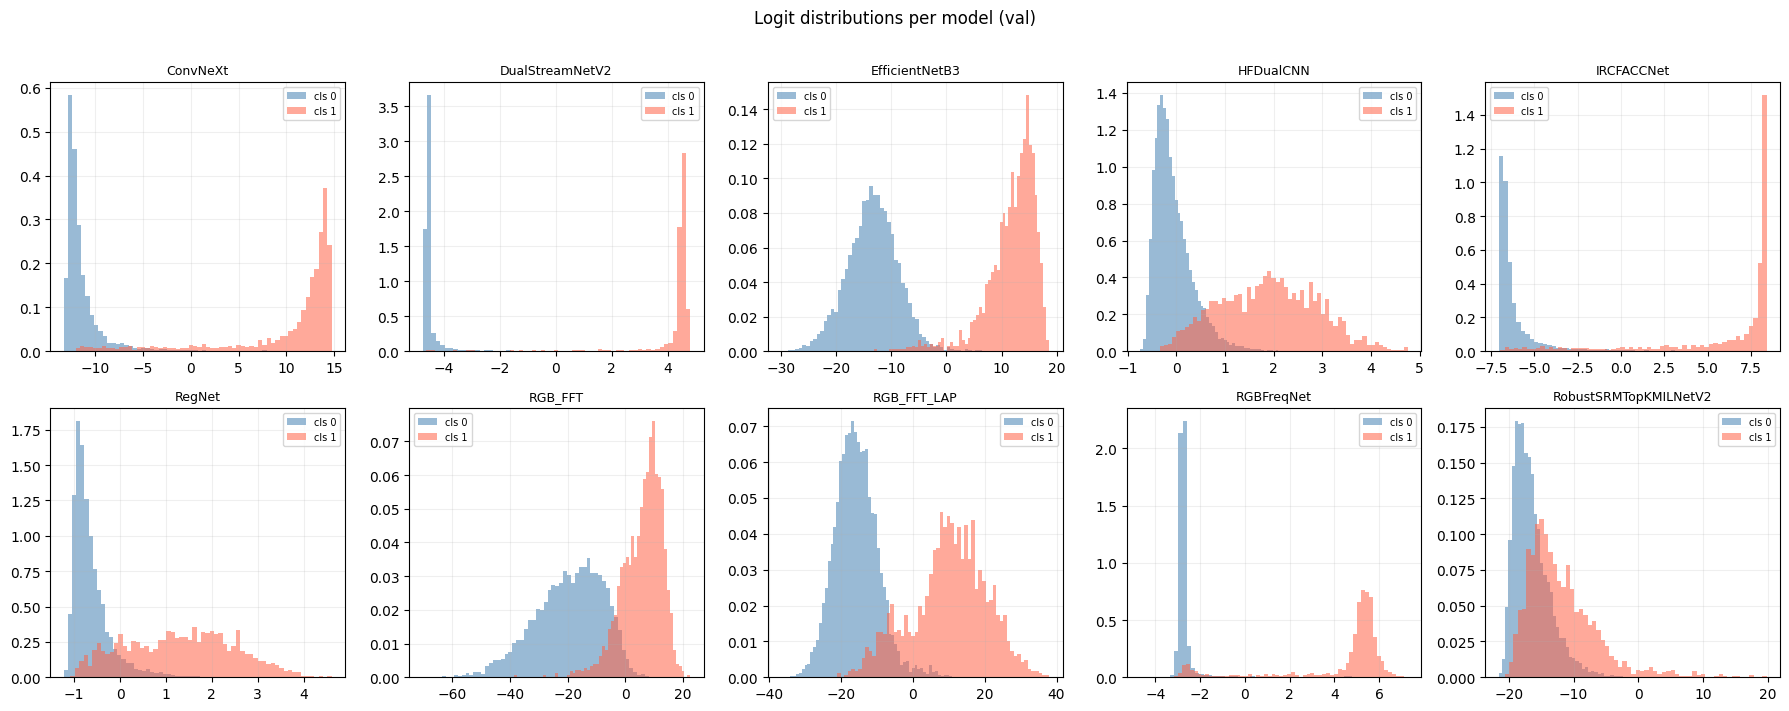

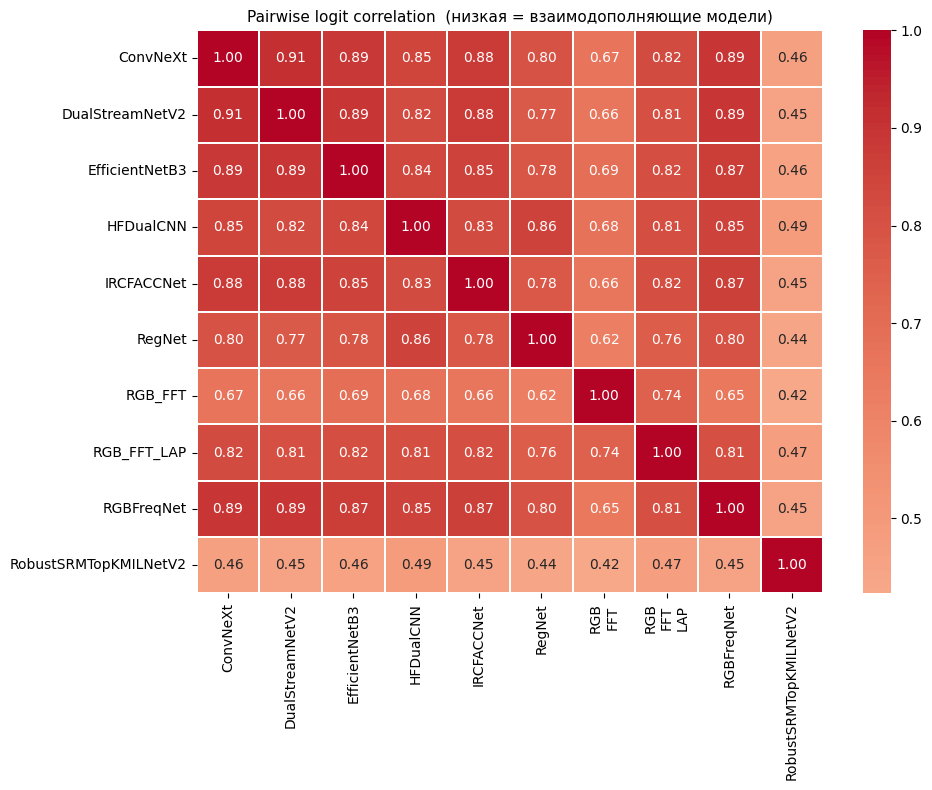

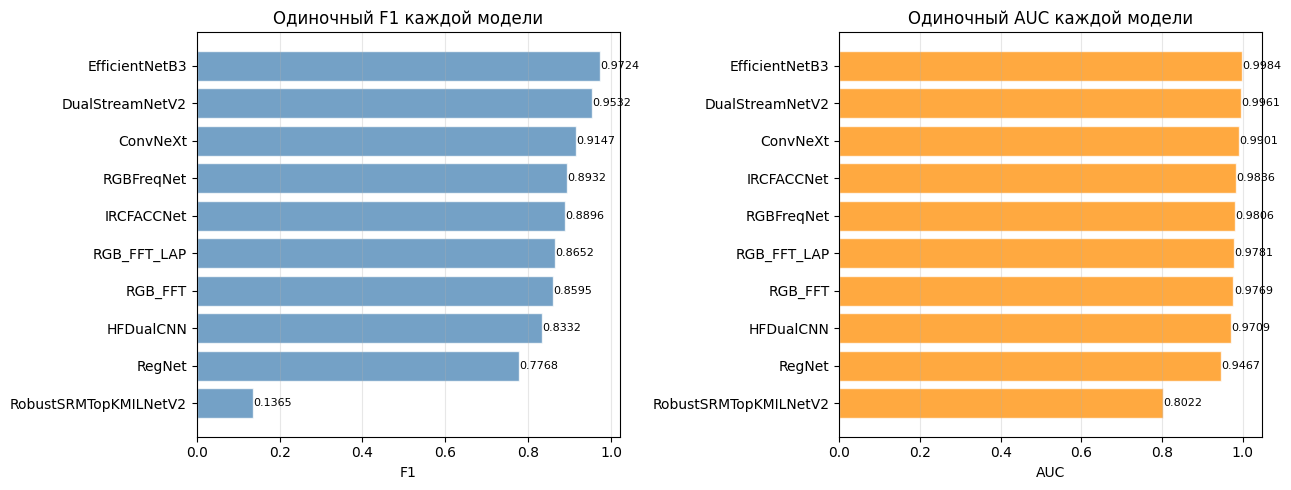

,model,AUC,F1
0,EfficientNetB3,0.9984,0.9724
1,DualStreamNetV2,0.9961,0.9532
2,ConvNeXt,0.9901,0.9147
3,RGBFreqNet,0.9806,0.8932
4,IRCFACCNet,0.9836,0.8896
5,RGB_FFT_LAP,0.9781,0.8652
6,RGB_FFT,0.9769,0.8595
7,HFDualCNN,0.9709,0.8332
8,RegNet,0.9467,0.7768
9,RobustSRMTopKMILNetV2,0.8022,0.1365


In [ ]:
LOGIT_COLS = [f"{m}_logit" for m in MODEL_NAMES]

# ── 1) Logit distributions ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for idx, ax in enumerate(axes.flat):
    col = LOGIT_COLS[idx]
    for lbl, clr in [(0, "steelblue"), (1, "tomato")]:
        ax.hist(meta_val_df.loc[meta_val_df.true_label == lbl, col],
                bins=60, alpha=0.55, color=clr, label=f"cls {lbl}", density=True)
    ax.set_title(MODEL_NAMES[idx], fontsize=9)
    ax.legend(fontsize=7); ax.grid(alpha=0.2)
plt.suptitle("Logit distributions per model (val)", y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

# ── 2) Correlation heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = meta_val_df[LOGIT_COLS].corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            xticklabels=[m.replace("_","\n") for m in MODEL_NAMES],
            yticklabels=MODEL_NAMES, ax=ax, linewidths=0.3)
ax.set_title("Pairwise logit correlation  (низкая = взаимодополняющие модели)", fontsize=11)
plt.tight_layout(); plt.show()

# ── 3) Одиночная AUC и F1 для каждой модели ─────────────────────────────────
from sklearn.metrics import roc_auc_score
y_arr = meta_val_df["true_label"].values
rows = []
for m in MODEL_NAMES:
    prob = 1 / (1 + np.exp(-meta_val_df[f"{m}_logit"].values))
    auc  = roc_auc_score(y_arr, prob)
    thrs = np.linspace(0.02, 0.98, 200)
    pred = prob[:,None] >= thrs[None,:]
    yt   = y_arr.astype(bool)
    tp   = (yt[:,None] &  pred).sum(0).astype(float)
    fp   = (~yt[:,None] &  pred).sum(0).astype(float)
    fn   = (yt[:,None] & ~pred).sum(0).astype(float)
    f1v  = 2*tp / (2*tp+fp+fn+1e-8)
    rows.append({"model": m, "AUC": auc, "F1": f1v.max()})

solo_df = pd.DataFrame(rows).sort_values("F1", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, clr in [(axes[0],"F1","steelblue"), (axes[1],"AUC","darkorange")]:
    d = solo_df.sort_values(col)
    ax.barh(d["model"], d[col], color=clr, alpha=0.75, edgecolor="white")
    ax.set_xlabel(col); ax.set_title(f"Одиночный {col} каждой модели"); ax.grid(axis="x",alpha=0.3)
    for i,(v,name) in enumerate(zip(d[col],d["model"])):
        ax.text(v+0.001, i, f"{v:.4f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()
display(solo_df.reset_index(drop=True).style.format({"AUC":"{:.4f}","F1":"{:.4f}"})
        .background_gradient(subset=["F1","AUC"], cmap="YlGn"))


# setup

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  ONE-TIME SETUP — данные на GPU, индексы фолдов, scaled матрица        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
y      = meta_val_df["true_label"].values.astype(np.float32)
X_full = meta_val_df[LOGIT_COLS].values.astype(np.float32)    # (N, 10)
X_test = meta_test_df[LOGIT_COLS].values.astype(np.float32)

GLOBAL_SCALER = StandardScaler()
X_scaled      = GLOBAL_SCALER.fit_transform(X_full).astype(np.float32)

SKF       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
FOLDS_IDX = [(tr, val) for tr, val in SKF.split(X_scaled, y)]

X_GPU = torch.from_numpy(X_scaled).to(DEVICE)
y_GPU = torch.from_numpy(y).to(DEVICE)

_min_tr  = min(len(tr) for tr,_ in FOLDS_IDX)
FOLD_Xtr = torch.stack([X_GPU[tr[:_min_tr]] for tr,_ in FOLDS_IDX])  # (K, N_tr, 10)
FOLD_ytr = torch.stack([y_GPU[tr[:_min_tr]] for tr,_ in FOLDS_IDX])  # (K, N_tr)

print(f"✅ GPU setup:  X_GPU={tuple(X_GPU.shape)}  FOLD_Xtr={tuple(FOLD_Xtr.shape)}")


✅ GPU setup:  X_GPU=(10000, 10)  FOLD_Xtr=(5, 8000, 10)


In [ ]:
# ── Vectorized F1 threshold sweep ───────────────────────────────────────────
def best_f1_vec(y_true: np.ndarray, y_prob: np.ndarray, n: int = 200):
    """~54x быстрее sklearn f1_score в цикле."""
    thrs = np.linspace(0.02, 0.98, n)
    pred = y_prob[:, None] >= thrs[None, :]
    yt   = y_true.astype(bool)
    tp   = ( yt[:, None] &  pred).sum(0).astype(np.float32)
    fp   = (~yt[:, None] &  pred).sum(0).astype(np.float32)
    fn   = ( yt[:, None] & ~pred).sum(0).astype(np.float32)
    f1   = 2 * tp / (2 * tp + fp + fn + 1e-8)
    idx  = int(f1.argmax())
    return float(thrs[idx]), float(f1[idx])

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -20, 20)))


# MLP

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  ТРИ MLP-ВАРИАНТА (vmap-совместимые: без BatchNorm, без Dropout)       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# ── 1. FastMetaMLP: skip-connection + blend scalar ───────────────────────────
# Начинает как взвешенное среднее, постепенно включает нелинейную ветвь.
class FastMetaMLP(nn.Module):
    """
    output = skip(x) + sigmoid(α) · branch(x)
    skip   = Linear(n→1)          → эквивалент LogReg
    branch = n → 2n → n → 1      → нелинейные взаимодействия
    α      = scalar, init=-2      → branch стартует выключенным
    """
    def __init__(self, n: int):
        super().__init__()
        h1, h2 = max(16, n*2), max(8, n)
        self.branch = nn.Sequential(
            nn.Linear(n, h1), nn.SiLU(),
            nn.Linear(h1, h2), nn.SiLU(),
            nn.Linear(h2, 1),
        )
        self.skip  = nn.Linear(n, 1)
        self.alpha = nn.Parameter(torch.tensor(-2.0))
        self._init()
    def _init(self):
        nn.init.constant_(self.skip.weight, 1.0 / self.skip.in_features)
        nn.init.zeros_(self.skip.bias)
        for m in self.branch.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)
    def forward(self, x):
        return self.skip(x) + torch.sigmoid(self.alpha) * self.branch(x)


# ── 2. AttentionMLP: контекстно-зависимые веса моделей ───────────────────────
# Ключевая идея: при n=10 моделях, логиты конкурируют через softmax-attention.
# Если модели A и B "спорят" (один +5, другой -5), attention это учитывает.
# Стандартная LogReg не может этого — у неё фиксированные веса.
class AttentionMLP(nn.Module):
    """
    w(x) = softmax(x @ W_a + b_a)
    attended = sum(w * x, dim=-1)
    output = attended + skip(x)

    Параметров: n*(n+1) + n+1 = n²+2n+1  → для n=10: 121 параметр
    """
    def __init__(self, n: int):
        super().__init__()
        self.W_a  = nn.Parameter(torch.zeros(n, n))   # attention matrix
        self.b_a  = nn.Parameter(torch.zeros(n))
        self.skip = nn.Linear(n, 1)
        self.temp = nn.Parameter(torch.ones(1))        # softmax temperature
        nn.init.constant_(self.skip.weight, 1.0 / n)
        nn.init.zeros_(self.skip.bias)
        nn.init.normal_(self.W_a, 0, 0.01)            # near-uniform attention at init
    def forward(self, x):
        # x: (batch, n)
        scores   = x @ self.W_a + self.b_a            # (batch, n)
        weights  = torch.softmax(scores / self.temp.clamp(min=0.1), dim=-1)
        attended = (weights * x).sum(-1, keepdim=True) # (batch, 1)
        return attended + self.skip(x)


# ── 3. GatedResidualMLP: GLU-style gating ────────────────────────────────────
# Вдохновлён Gated Linear Units (GLU) из NLP.
# gate(x) = sigmoid(W_g @ x) — решает ЧТО пропустить
# val(x)  = tanh(W_v @ x)    — решает КАК преобразовать
# output  = gate ⊙ val + skip(x)
# Особенность: при n≤10 скрытый слой h = n*2,
# модель "разбирает" логиты на компоненты, затем избирательно складывает.
class GatedResidualMLP(nn.Module):
    """
    h = max(16, 2n)
    gate = sigmoid(Linear(n → h))   — мягкий отбор признаков
    val  = tanh(Linear(n → h))      — трансформация
    gated_hidden = gate ⊙ val       — GLU-блок
    output = Linear(h → 1)(gated_hidden) + skip(x)
    """
    def __init__(self, n: int):
        super().__init__()
        h = max(16, n * 2)
        self.W_gate = nn.Linear(n, h)
        self.W_val  = nn.Linear(n, h)
        self.out    = nn.Linear(h, 1)
        self.skip   = nn.Linear(n, 1)
        self._init(n)
    def _init(self, n):
        nn.init.constant_(self.skip.weight, 1.0 / n)
        nn.init.zeros_(self.skip.bias)
        for lin in [self.W_gate, self.W_val, self.out]:
            nn.init.normal_(lin.weight, 0, 0.01); nn.init.zeros_(lin.bias)
    def forward(self, x):
        gate   = torch.sigmoid(self.W_gate(x))
        val    = torch.tanh(self.W_val(x))
        gated  = gate * val
        return self.out(gated) + self.skip(x)


# ── MetaMLP для финального обучения (с BN + Dropout) ─────────────────────────
class MetaMLP(nn.Module):
    def __init__(self, n: int):
        super().__init__()
        h1, h2 = max(16, n*2), max(8, n)
        self.branch = nn.Sequential(
            nn.Linear(n, h1), nn.BatchNorm1d(h1), nn.SiLU(), nn.Dropout(0.35),
            nn.Linear(h1, h2), nn.BatchNorm1d(h2), nn.SiLU(), nn.Dropout(0.25),
            nn.Linear(h2, 1),
        )
        self.skip  = nn.Linear(n, 1)
        self.alpha = nn.Parameter(torch.tensor(-2.0))
        nn.init.constant_(self.skip.weight, 1.0/n); nn.init.zeros_(self.skip.bias)
        for m in self.branch.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight,0,0.01); nn.init.zeros_(m.bias)
    def forward(self, x):
        return self.skip(x) + torch.sigmoid(self.alpha) * self.branch(x)


# ── Краткая сводка параметров ─────────────────────────────────────────────────
print("MLP architectures (n=10 features):")
print(f"{'Model':<22} {'Params':>8}  Description")
print("-"*60)
for cls, desc in [
    (FastMetaMLP,      "skip + blend scalar  →  LogReg + nonlinear correction"),
    (AttentionMLP,     "softmax attention    →  context-aware model weighting"),
    (GatedResidualMLP, "GLU-style gating     →  selective feature routing"),
    (MetaMLP,          "BN+Dropout version   →  только для финального обучения"),
]:
    m = cls(10)
    n = sum(p.numel() for p in m.parameters())
    print(f"  {cls.__name__:<20} {n:>8}  {desc}")


MLP architectures (n=10 features):
Model                    Params  Description
------------------------------------------------------------
  FastMetaMLP               453  skip + blend scalar  →  LogReg + nonlinear correction
  AttentionMLP              122  softmax attention    →  context-aware model weighting
  GatedResidualMLP          472  GLU-style gating     →  selective feature routing
  MetaMLP                   513  BN+Dropout version   →  только для финального обучения


# Вспомогательные функции

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  vmap-УСКОРЕННОЕ CV: все 5 фолдов ОДНОВРЕМЕННО                        ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def _stacked_params(model_cls, input_dim: int, K: int) -> dict:
    """K независимых инициализаций, стакованных по dim-0."""
    stacks = None
    for _ in range(K):
        m = model_cls(input_dim)
        if stacks is None:
            stacks = {n: [] for n,_ in m.named_parameters()}
        for n, p in m.named_parameters():
            stacks[n].append(p.detach().clone())
    return {n: torch.stack(v).to(DEVICE) for n, v in stacks.items()}

def _fwd_loss(params, model_tpl, x, y):
    return F.binary_cross_entropy_with_logits(
        functional_call(model_tpl, params, x).squeeze(-1), y)

def _fwd_prob(params, model_tpl, x):
    return torch.sigmoid(functional_call(model_tpl, params, x).squeeze(-1))


def cv_mlp_vmap(col_indices: tuple, model_cls) -> tuple:
    """
    Универсальная vmap-CV функция для любого из трёх MLP-классов.
    Early stopping: по val BCE loss раз в SEARCH_CHECK_N эпох.
    Threshold sweep: ОДИН РАЗ после CV (не в цикле эпох!).
    """
    K, D = N_FOLDS, len(col_indices)
    cols = list(col_indices)

    fold_Xtr = FOLD_Xtr[:, :, cols]     # (K, N_tr, D)
    fold_ytr = FOLD_ytr                  # (K, N_tr)

    params = _stacked_params(model_cls, D, K)
    m_s  = {k: torch.zeros_like(v) for k,v in params.items()}
    v_s  = {k: torch.zeros_like(v) for k,v in params.items()}
    b1, b2, eps = 0.9, 0.999, 1e-8
    lr,  wd     = SEARCH_LR, SEARCH_WD

    model_tpl     = model_cls(D).to(DEVICE)
    batched_grad  = vmap(grad(_fwd_loss, argnums=0), in_dims=(0, None, 0, 0))
    batched_prob  = vmap(_fwd_prob,                  in_dims=(0, None, 0))

    best_val_loss = torch.full((K,), float("inf"))
    no_imp        = np.zeros(K, dtype=int)
    stopped       = np.zeros(K, dtype=bool)
    best_probs    = [np.full(len(FOLDS_IDX[k][1]), 0.5) for k in range(K)]

    for step in range(1, SEARCH_EPOCHS + 1):
        if stopped.all():
            break
        grads = batched_grad(params, model_tpl, fold_Xtr, fold_ytr)
        with torch.no_grad():
            for name in params:
                g = grads[name]
                m_s[name]  = b1 * m_s[name] + (1 - b1) * g
                v_s[name]  = b2 * v_s[name] + (1 - b2) * g * g
                mh = m_s[name] / (1 - b1**step)
                vh = v_s[name] / (1 - b2**step)
                params[name] = params[name] * (1 - lr*wd) - lr * mh / (vh.sqrt() + eps)

        if step % SEARCH_CHECK_N == 0:
            with torch.no_grad():
                for k in range(K):
                    if stopped[k]: continue
                    _, val_idx = FOLDS_IDX[k]
                    Xv = X_GPU[val_idx][:, cols]
                    yv = y_GPU[val_idx]
                    p_k = {nm: v[k] for nm,v in params.items()}
                    probs    = _fwd_prob(p_k, model_tpl, Xv)
                    val_loss = F.binary_cross_entropy(probs, yv).item()
                    if val_loss < best_val_loss[k] - 1e-4:
                        best_val_loss[k] = val_loss
                        best_probs[k]    = probs.cpu().numpy()
                        no_imp[k]        = 0
                    else:
                        no_imp[k] += 1
                    if no_imp[k] >= SEARCH_PATIENCE // SEARCH_CHECK_N:
                        stopped[k] = True

    oof_probs = np.zeros(len(y))
    fold_f1s  = []
    for k in range(K):
        _, val_idx     = FOLDS_IDX[k]
        oof_probs[val_idx] = best_probs[k]
        _, f1          = best_f1_vec(y[val_idx], best_probs[k])
        fold_f1s.append(f1)
    _, oof_f1 = best_f1_vec(y, oof_probs)
    return float(np.mean(fold_f1s)), float(np.std(fold_f1s)), oof_f1, oof_probs


# ── LogReg CV ────────────────────────────────────────────────────────────────
def cv_logreg(col_indices: tuple) -> tuple:
    cols, X_sub = list(col_indices), X_full[:, list(col_indices)]
    oof_probs   = np.zeros(len(y))
    fold_f1s    = []
    for tr, val in FOLDS_IDX:
        sc  = StandardScaler()
        clf = LogisticRegression(max_iter=500, C=1.0, solver="liblinear")
        clf.fit(sc.fit_transform(X_sub[tr]), y[tr])
        probs          = clf.predict_proba(sc.transform(X_sub[val]))[:, 1]
        oof_probs[val] = probs
        _, f1          = best_f1_vec(y[val], probs)
        fold_f1s.append(f1)
    _, oof_f1 = best_f1_vec(y, oof_probs)
    return float(np.mean(fold_f1s)), float(np.std(fold_f1s)), oof_f1, oof_probs


# ── Sklearn-based CV (общая функция для деревьев) ────────────────────────────
def cv_sklearn(col_indices: tuple, make_clf) -> tuple:
    X_sub     = X_full[:, list(col_indices)]
    oof_probs = np.zeros(len(y))
    fold_f1s  = []
    for tr, val in FOLDS_IDX:
        sc  = StandardScaler()
        clf = make_clf()
        clf.fit(sc.fit_transform(X_sub[tr]), y[tr].astype(int))
        probs          = clf.predict_proba(sc.transform(X_sub[val]))[:, 1]
        oof_probs[val] = probs
        _, f1          = best_f1_vec(y[val], probs)
        fold_f1s.append(f1)
    _, oof_f1 = best_f1_vec(y, oof_probs)
    return float(np.mean(fold_f1s)), float(np.std(fold_f1s)), oof_f1, oof_probs


# Прогрев

In [ ]:
# ── Прогрев JIT-компилятора для всех трёх MLP-вариантов ─────────────────────
print("🔥 Прогрев GPU…")
_wc = tuple(range(N_MODELS))
for cls, name in [(FastMetaMLP,"FastMetaMLP"), (AttentionMLP,"AttentionMLP"),
                   (GatedResidualMLP,"GatedResidualMLP")]:
    t0 = time.perf_counter()
    cv_mlp_vmap(_wc, cls)
    print(f"   {name:<22}: {time.perf_counter()-t0:.2f}s (warmup)")

# Замер на трёх размерах
print("\n⏱️  Бенчмарк (после прогрева):")
for cls, name in [(FastMetaMLP,"FastMLP"), (AttentionMLP,"AttnMLP"),
                   (GatedResidualMLP,"GatedMLP")]:
    times = []
    for nc in [1, 5, 10]:
        t0 = time.perf_counter()
        cv_mlp_vmap(tuple(range(nc)), cls)
        times.append(time.perf_counter()-t0)
    avg = np.mean(times)
    print(f"   {name:<12}: n=1→{times[0]:.2f}s  n=5→{times[1]:.2f}s  n=10→{times[2]:.2f}s"
          f"  avg={avg:.2f}s  ETA={1023*avg/60:.1f}min")


🔥 Прогрев GPU…
   FastMetaMLP           : 7.70s (warmup)
   AttentionMLP          : 1.27s (warmup)
   GatedResidualMLP      : 0.40s (warmup)

⏱️  Бенчмарк (после прогрева):
   FastMLP     : n=1→0.43s  n=5→0.40s  n=10→0.41s  avg=0.41s  ETA=7.0min
   AttnMLP     : n=1→0.30s  n=5→0.28s  n=10→0.29s  avg=0.29s  ETA=5.0min
   GatedMLP    : n=1→0.37s  n=5→0.37s  n=10→0.39s  avg=0.37s  ETA=6.4min


# фаза 1

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  ФАЗА 1: все 1023 комбинации × 4 мета-алгоритма                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝
all_combos = [
    combo
    for r in range(1, N_MODELS + 1)
    for combo in combinations(range(N_MODELS), r)
]
print(f"🔍 Комбинаций: {len(all_combos)}  (2^{N_MODELS}-1)")

results_p1 = {
    "logreg":   [],
    "fast_mlp": [],
    "attn_mlp": [],
    "gated_mlp":[],
}

t_start = time.perf_counter()
pbar = tqdm(all_combos, desc="Phase 1", unit="combo")

for i, combo in enumerate(pbar, 1):
    label = "+".join(MODEL_NAMES[j] for j in combo)
    n     = len(combo)

    lr_m, lr_s, lr_oof, _      = cv_logreg(combo)
    fm_m, fm_s, fm_oof, _      = cv_mlp_vmap(combo, FastMetaMLP)
    am_m, am_s, am_oof, _      = cv_mlp_vmap(combo, AttentionMLP)
    gm_m, gm_s, gm_oof, _     = cv_mlp_vmap(combo, GatedResidualMLP)

    row = dict(combo=label, n_models=n, idx=combo)
    results_p1["logreg"   ].append({**row, "f1_mean":lr_m, "f1_std":lr_s, "f1_oof":lr_oof})
    results_p1["fast_mlp" ].append({**row, "f1_mean":fm_m, "f1_std":fm_s, "f1_oof":fm_oof})
    results_p1["attn_mlp" ].append({**row, "f1_mean":am_m, "f1_std":am_s, "f1_oof":am_oof})
    results_p1["gated_mlp"].append({**row, "f1_mean":gm_m, "f1_std":gm_s, "f1_oof":gm_oof})

    elapsed = time.perf_counter() - t_start
    eta     = elapsed / i * (len(all_combos) - i)
    pbar.set_postfix({
        "LR":  f"{lr_oof:.4f}", "FM": f"{fm_oof:.4f}",
        "AM":  f"{am_oof:.4f}", "GM": f"{gm_oof:.4f}",
        "ETA": f"{eta/60:.1f}m",
    })

# Конвертируем в DataFrame и сортируем
dfs_p1 = {k: pd.DataFrame(v).sort_values("f1_oof", ascending=False).reset_index(drop=True)
           for k, v in results_p1.items()}

t_total = time.perf_counter() - t_start
print(f"\n✅ Фаза 1 завершена за {t_total/60:.1f} мин  ({t_total/len(all_combos):.2f}s/combo)")
for k, df in dfs_p1.items():
    print(f"  {k:<12}: best OOF F1={df.iloc[0]['f1_oof']:.4f}  "
          f"combo={df.iloc[0]['combo'][:55]}")


🔍 Комбинаций: 1023  (2^10-1)


Phase 1:   0%|          | 0/1023 [00:00<?, ?combo/s]


✅ Фаза 1 завершена за 20.2 мин  (1.18s/combo)
  logreg      : best OOF F1=0.9855  combo=DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+Reg
  fast_mlp    : best OOF F1=0.9791  combo=DualStreamNetV2+EfficientNetB3+IRCFACCNet
  attn_mlp    : best OOF F1=0.9808  combo=DualStreamNetV2+EfficientNetB3+IRCFACCNet+RGB_FFT+Robus
  gated_mlp   : best OOF F1=0.9801  combo=DualStreamNetV2+EfficientNetB3+IRCFACCNet+RGB_FFT+Robus


# фаза 2

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  ФАЗА 2: топ-50 комбинаций × деревья (LightGBM, RF, GradBoost)        ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# Отбираем топ-K уникальных комбинаций по максимальному F1 среди всех phase-1 моделей
_all_p1 = pd.concat([df.assign(algo=k) for k, df in dfs_p1.items()])
top_combos_labels = (
    _all_p1.groupby("combo")["f1_oof"].max()
    .nlargest(PHASE2_TOP_K).index.tolist()
)
combo_lookup = {"+".join(MODEL_NAMES[j] for j in c): c
                for c in all_combos}
top_combos   = [combo_lookup[lbl] for lbl in top_combos_labels if lbl in combo_lookup]
print(f"🎯 Топ-{len(top_combos)} комбинаций отобрано для Phase 2")
print(f"   Размеры: {sorted(set(len(c) for c in top_combos))}")

# Конфигурации деревьев
TREE_CFGS = {
    "lightgbm": lambda: lgb.LGBMClassifier(
        n_estimators=200, num_leaves=15, learning_rate=0.05,
        min_child_samples=20, reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=1, verbose=-1, random_state=RANDOM_STATE),

    "random_forest": lambda: RandomForestClassifier(
        n_estimators=100, max_depth=4, min_samples_leaf=10,
        max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE),

    "grad_boost": lambda: GradientBoostingClassifier(
        n_estimators=100, max_depth=2, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=10, random_state=RANDOM_STATE),
}

results_p2 = {k: [] for k in TREE_CFGS}

t_start = time.perf_counter()
pbar2 = tqdm(top_combos, desc="Phase 2 (trees)", unit="combo")
for combo in pbar2:
    label = "+".join(MODEL_NAMES[j] for j in combo)
    for algo, make_clf in TREE_CFGS.items():
        m, s, oof, _ = cv_sklearn(combo, make_clf)
        results_p2[algo].append(dict(combo=label, n_models=len(combo),
                                     f1_mean=m, f1_std=s, f1_oof=oof, idx=combo))
    pbar2.set_postfix({k: f"{results_p2[k][-1]['f1_oof']:.4f}" for k in TREE_CFGS})

dfs_p2 = {k: pd.DataFrame(v).sort_values("f1_oof", ascending=False).reset_index(drop=True)
          for k, v in results_p2.items()}

t_total = time.perf_counter() - t_start
print(f"\n✅ Фаза 2 завершена за {t_total/60:.1f} мин")
for k, df in dfs_p2.items():
    print(f"  {k:<16}: best OOF F1={df.iloc[0]['f1_oof']:.4f}  "
          f"combo={df.iloc[0]['combo'][:50]}")


🎯 Топ-50 комбинаций отобрано для Phase 2
   Размеры: [5, 6, 7, 8, 9, 10]


Phase 2 (trees):   0%|          | 0/50 [00:00<?, ?combo/s]


✅ Фаза 2 завершена за 10.6 мин
  lightgbm        : best OOF F1=0.9840  combo=DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNe
  random_forest   : best OOF F1=0.9825  combo=DualStreamNetV2+EfficientNetB3+IRCFACCNet+RegNet+R
  grad_boost      : best OOF F1=0.9814  combo=DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNe


# **Сводная таблица результатов, графики**

In [ ]:
# ── Топ-10 для каждого алгоритма ────────────────────────────────────────────
DCOLS = ["combo", "n_models", "f1_mean", "f1_std", "f1_oof"]
FMT   = {"f1_mean":"{:.4f}", "f1_std":"{:.4f}", "f1_oof":"{:.4f}"}
CMAPS = {"logreg":"Blues","fast_mlp":"Oranges","attn_mlp":"Greens",
         "gated_mlp":"Purples","lightgbm":"YlOrRd","random_forest":"BuGn","grad_boost":"PuRd"}

all_dfs = {**dfs_p1, **dfs_p2}
for k, df in all_dfs.items():
    print(f"\n{'═'*70}")
    print(f"🏆  TOP-10  |  {k.upper().replace('_',' ')}")
    print(f"{'═'*70}")
    display(df[DCOLS].head(10).style
            .background_gradient(subset=["f1_oof"], cmap=CMAPS.get(k,"YlGn"))
            .format(FMT))

# Сохраняем все таблицы
for k, df in all_dfs.items():
    df[DCOLS].to_csv(f"/content/{k}_results.csv", index=False)
print("\n💾 Все таблицы сохранены в /content/")



══════════════════════════════════════════════════════════════════════
🏆  TOP-10  |  LOGREG
══════════════════════════════════════════════════════════════════════


,combo,n_models,f1_mean,f1_std,f1_oof
0,DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT+RGB_FFT_LAP+RGBFreqNet,8,0.9870,0.0022,0.9855
1,DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT_LAP+RGBFreqNet,7,0.9862,0.0030,0.9855
2,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT_LAP,7,0.9870,0.0030,0.9855
3,DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT+RGB_FFT_LAP+RGBFreqNet+RobustSRMTopKMILNetV2,9,0.9867,0.0025,0.9852
4,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT_LAP+RGBFreqNet,8,0.9864,0.0035,0.9852
5,DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT_LAP,6,0.9864,0.0030,0.9852
6,DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT+RGBFreqNet,7,0.9861,0.0029,0.9852
7,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT+RGB_FFT_LAP+RGBFreqNet,9,0.9864,0.0026,0.9852
8,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT+RGB_FFT_LAP,8,0.9873,0.0028,0.9851
9,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT+RGBFreqNet,8,0.9865,0.0033,0.9849



══════════════════════════════════════════════════════════════════════
🏆  TOP-10  |  FAST MLP
══════════════════════════════════════════════════════════════════════


,combo,n_models,f1_mean,f1_std,f1_oof
0,DualStreamNetV2+EfficientNetB3+IRCFACCNet,3,0.9816,0.0062,0.9791
1,DualStreamNetV2+EfficientNetB3+IRCFACCNet+RGB_FFT_LAP,4,0.9799,0.0053,0.9783
2,DualStreamNetV2+EfficientNetB3+IRCFACCNet+RGB_FFT,4,0.9794,0.0056,0.9781
3,DualStreamNetV2+EfficientNetB3+RGB_FFT_LAP,3,0.9810,0.0044,0.9778
4,DualStreamNetV2+EfficientNetB3+IRCFACCNet+RGB_FFT+RGB_FFT_LAP,5,0.9787,0.0056,0.9775
5,DualStreamNetV2+EfficientNetB3+IRCFACCNet+RGB_FFT+RobustSRMTopKMILNetV2,5,0.9790,0.0043,0.9772
6,ConvNeXt+DualStreamNetV2+EfficientNetB3+RGB_FFT_LAP,4,0.9790,0.0067,0.9766
7,ConvNeXt+DualStreamNetV2+EfficientNetB3+IRCFACCNet,4,0.9788,0.0066,0.9765
8,ConvNeXt+DualStreamNetV2+EfficientNetB3+IRCFACCNet+RGB_FFT,5,0.9772,0.0066,0.9764
9,DualStreamNetV2+EfficientNetB3+IRCFACCNet+RobustSRMTopKMILNetV2,4,0.9789,0.0058,0.9762



══════════════════════════════════════════════════════════════════════
🏆  TOP-10  |  ATTN MLP
══════════════════════════════════════════════════════════════════════


...


══════════════════════════════════════════════════════════════════════
🏆  TOP-10  |  RANDOM FOREST
══════════════════════════════════════════════════════════════════════


,combo,n_models,f1_mean,f1_std,f1_oof
0,DualStreamNetV2+EfficientNetB3+IRCFACCNet+RegNet+RGB_FFT+RGB_FFT_LAP+RGBFreqNet+RobustSRMTopKMILNetV2,8,0.9826,0.0040,0.9825
1,DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT_LAP,6,0.9826,0.0041,0.9813
2,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT_LAP,7,0.9831,0.0054,0.9811
3,ConvNeXt+DualStreamNetV2+EfficientNetB3+IRCFACCNet+RegNet+RGB_FFT_LAP+RGBFreqNet+RobustSRMTopKMILNetV2,8,0.9840,0.0061,0.9810
4,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RGB_FFT_LAP+RGBFreqNet+RobustSRMTopKMILNetV2,8,0.9831,0.0061,0.9808
5,ConvNeXt+DualStreamNetV2+EfficientNetB3+IRCFACCNet+RegNet+RGB_FFT+RGB_FFT_LAP+RGBFreqNet,8,0.9825,0.0052,0.9808
6,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT_LAP+RGBFreqNet,8,0.9828,0.0059,0.9808
7,ConvNeXt+DualStreamNetV2+EfficientNetB3+IRCFACCNet+RegNet+RGB_FFT_LAP,6,0.9825,0.0067,0.9808
8,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT+RGB_FFT_LAP+RobustSRMTopKMILNetV2,9,0.9828,0.0050,0.9808
9,DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RGB_FFT+RGB_FFT_LAP+RGBFreqNet,7,0.9820,0.0050,0.9807



══════════════════════════════════════════════════════════════════════
🏆  TOP-10  |  GRAD BOOST
══════════════════════════════════════════════════════════════════════


,combo,n_models,f1_mean,f1_std,f1_oof
0,DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT,6,0.9836,0.0061,0.9814
1,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT+RGB_FFT_LAP+RGBFreqNet+RobustSRMTopKMILNetV2,10,0.9825,0.0061,0.9812
2,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RGB_FFT_LAP,6,0.9831,0.0059,0.9812
3,DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT+RGBFreqNet,7,0.9836,0.0062,0.9811
4,DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT+RGBFreqNet+RobustSRMTopKMILNetV2,8,0.9836,0.0062,0.9811
5,DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGBFreqNet,6,0.9839,0.0060,0.9811
6,DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT+RobustSRMTopKMILNetV2,7,0.9836,0.0061,0.9810
7,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RGB_FFT_LAP+RGBFreqNet+RobustSRMTopKMILNetV2,8,0.9828,0.0064,0.9810
8,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT_LAP,7,0.9831,0.0064,0.9809
9,ConvNeXt+DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT+RGB_FFT_LAP,8,0.9828,0.0063,0.9809



💾 Все таблицы сохранены в /content/


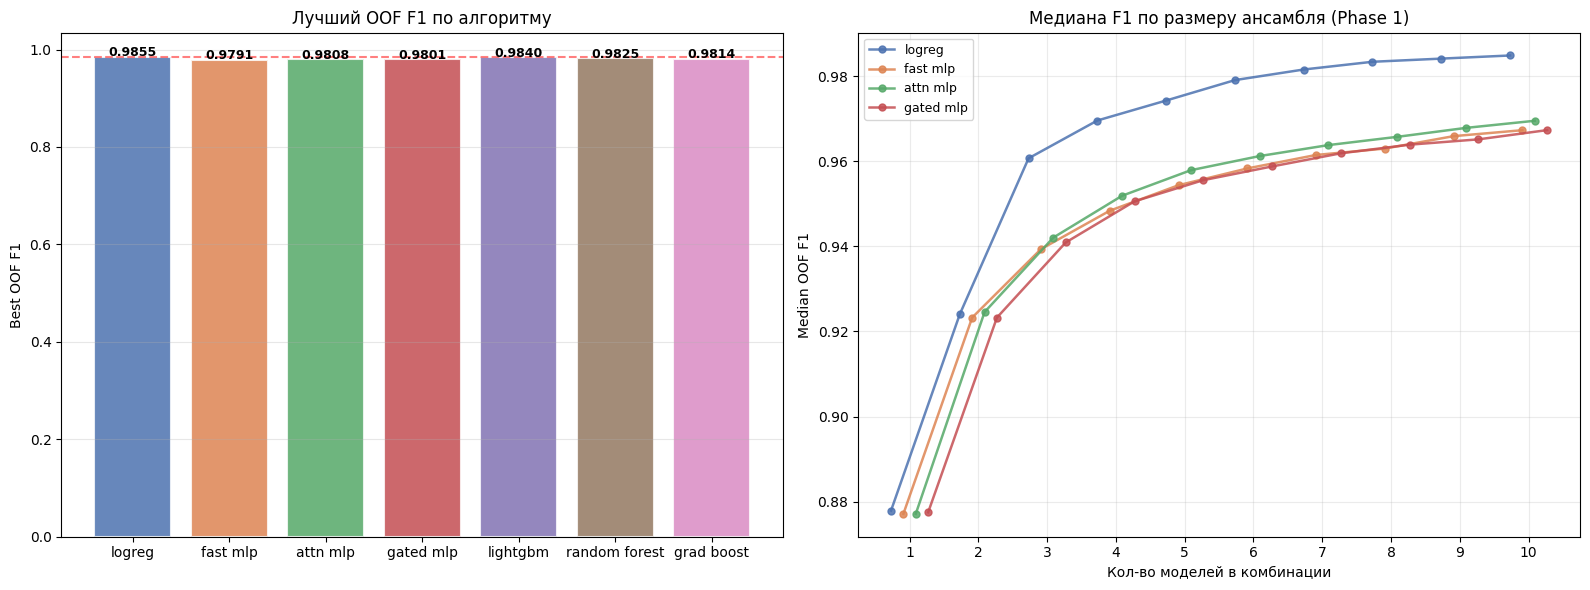

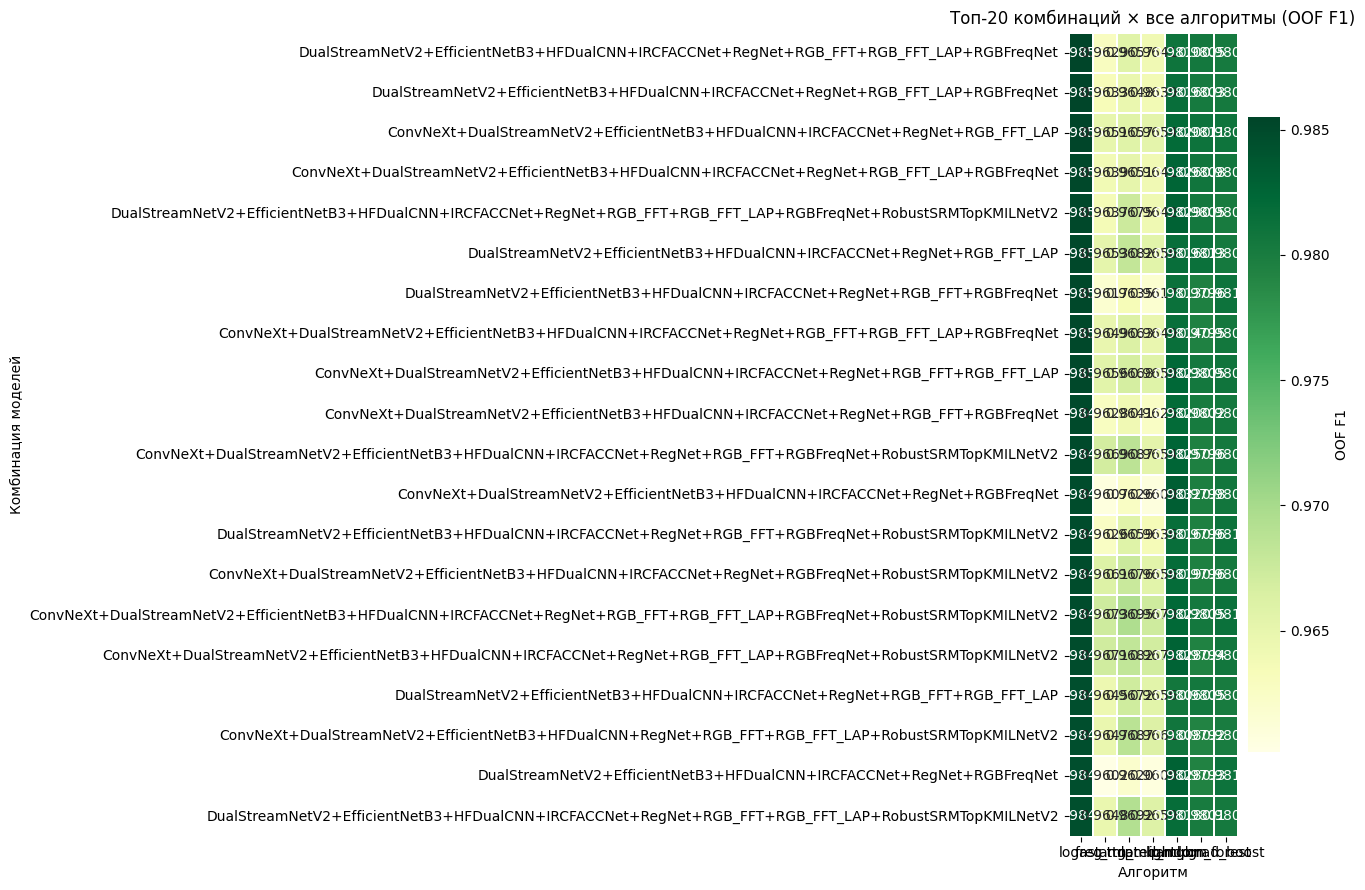

In [ ]:
# ── Сравнение всех алгоритмов ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 1) Best OOF F1 по каждому алгоритму ──────────────────────────────────────
algo_names = list(all_dfs.keys())
best_f1s   = [all_dfs[k].iloc[0]["f1_oof"] for k in algo_names]
colors     = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860","#DA8BC3"]
bars = axes[0].bar([a.replace("_"," ") for a in algo_names], best_f1s,
                   color=colors, alpha=0.85, edgecolor="white", linewidth=1.5)
axes[0].set_ylabel("Best OOF F1"); axes[0].set_title("Лучший OOF F1 по алгоритму")
axes[0].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, best_f1s):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.0005,
                 f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
best_overall = max(best_f1s)
axes[0].axhline(best_overall, color="red", ls="--", alpha=0.5, lw=1.5)

# ── 2) Boxplot: F1 по размеру ансамбля (Phase 1 модели) ──────────────────────
phase1_labels = ["logreg","fast_mlp","attn_mlp","gated_mlp"]
data_by_n = {k: [all_dfs[k][all_dfs[k]["n_models"]==n]["f1_oof"].values
                 for n in range(1, N_MODELS+1)]
             for k in phase1_labels}

x_pos  = np.arange(1, N_MODELS+1)
width  = 0.18
for i, (k, clr) in enumerate(zip(phase1_labels, colors)):
    offsets = (i - 1.5) * width
    medians = [np.median(v) if len(v)>0 else 0 for v in data_by_n[k]]
    axes[1].plot(x_pos + offsets, medians, "o-", color=clr, label=k.replace("_"," "),
                 linewidth=1.8, markersize=5, alpha=0.85)
axes[1].set_xlabel("Кол-во моделей в комбинации")
axes[1].set_ylabel("Median OOF F1")
axes[1].set_title("Медиана F1 по размеру ансамбля (Phase 1)")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.25)
axes[1].set_xticks(x_pos)

plt.tight_layout(); plt.show()

# ── 3) Тепловая карта: топ-20 комбинаций × все алгоритмы ──────────────────
# (только для Phase 2 и Phase 1 на пересечении топ-50)
top20 = (
    pd.concat([all_dfs[k][["combo","f1_oof"]].assign(algo=k)
               for k in all_dfs])
    .groupby("combo")["f1_oof"].max()
    .nlargest(20).index.tolist()
)
hmap_rows = []
for combo_lbl in top20:
    row = {"combo": combo_lbl}
    for k, df in all_dfs.items():
        hit = df[df["combo"] == combo_lbl]
        row[k] = hit.iloc[0]["f1_oof"] if len(hit) > 0 else np.nan
    hmap_rows.append(row)
hmap_df = pd.DataFrame(hmap_rows).set_index("combo")

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(hmap_df, annot=True, fmt=".4f", cmap="YlGn", linewidths=0.3,
            ax=ax, cbar_kws={"label":"OOF F1"}, vmin=hmap_df.min().min())
ax.set_title("Топ-20 комбинаций × все алгоритмы (OOF F1)", fontsize=12)
ax.set_xlabel("Алгоритм"); ax.set_ylabel("Комбинация моделей")
plt.tight_layout(); plt.show()


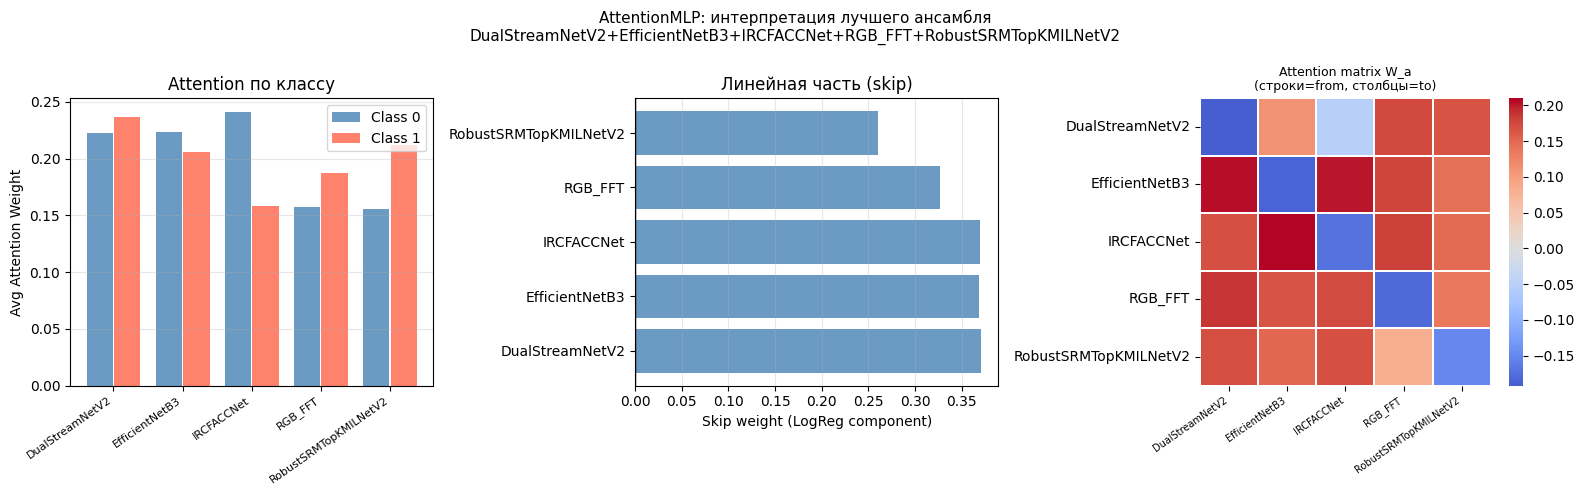

In [ ]:
# ── Анализ весов AttentionMLP: кому доверяет лучший ансамбль? ───────────────
best_attn_combo = dfs_p1["attn_mlp"].iloc[0]["idx"]
best_attn_names = [MODEL_NAMES[i] for i in best_attn_combo]
D = len(best_attn_combo)

# Обучим финальную AttentionMLP на всех данных
X_attn = X_scaled[:, list(best_attn_combo)]
sc_attn = StandardScaler(); X_a = sc_attn.fit_transform(X_attn).astype(np.float32)
Xa_t = torch.FloatTensor(X_a).to(DEVICE)
ya_t = torch.FloatTensor(y).unsqueeze(1).to(DEVICE)

model_viz = AttentionMLP(D).to(DEVICE)
opt = torch.optim.AdamW(model_viz.parameters(), lr=FINAL_LR, weight_decay=FINAL_WD)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FINAL_EPOCHS, eta_min=1e-5)
for ep in range(FINAL_EPOCHS):
    model_viz.train()
    opt.zero_grad()
    F.binary_cross_entropy_with_logits(model_viz(Xa_t), ya_t).backward()
    nn.utils.clip_grad_norm_(model_viz.parameters(), 1.0)
    opt.step(); sch.step()

# Извлечём attention-матрицу
model_viz.eval()
with torch.no_grad():
    attn_probs = torch.softmax(Xa_t @ model_viz.W_a + model_viz.b_a, dim=-1)
    # Средние веса: для класса 0 и класса 1
    y_bin = torch.from_numpy(y).bool().to(DEVICE)
    attn_cls0 = attn_probs[~y_bin].mean(0).cpu().numpy()
    attn_cls1 = attn_probs[ y_bin].mean(0).cpu().numpy()
    skip_w    = model_viz.skip.weight.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Attention weights by class
x_pos = np.arange(D)
axes[0].bar(x_pos - 0.2, attn_cls0, 0.38, label="Class 0", color="steelblue", alpha=0.8)
axes[0].bar(x_pos + 0.2, attn_cls1, 0.38, label="Class 1", color="tomato",    alpha=0.8)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(best_attn_names, rotation=35, ha="right", fontsize=8)
axes[0].set_ylabel("Avg Attention Weight"); axes[0].set_title("Attention по классу")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

# Skip weights (= LogReg-часть)
axes[1].barh(best_attn_names, skip_w, color=["tomato" if w<0 else "steelblue" for w in skip_w], alpha=0.8)
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("Skip weight (LogReg component)")
axes[1].set_title(f"Линейная часть (skip)") # Removed alpha_v reference
axes[1].grid(axis="x", alpha=0.3)

# Attention matrix (W_a)
W_np = model_viz.W_a.detach().cpu().numpy()
sns.heatmap(W_np, xticklabels=best_attn_names, yticklabels=best_attn_names,
            annot=False, cmap="coolwarm", center=0, ax=axes[2], linewidths=0.2)
axes[2].set_title("Attention matrix W_a\n(строки=from, столбцы=to)", fontsize=9)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=35, ha="right", fontsize=7)

plt.suptitle(f"AttentionMLP: интерпретация лучшего ансамбля\n{'+'.join(best_attn_names)}", fontsize=11)
plt.tight_layout(); plt.show()
# Removed the print statement referencing alpha_v as it's not applicable to AttentionMLP

# финальное обучение лучшей модели

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  ФИНАЛЬНАЯ МОДЕЛЬ: лучший алгоритм + лучшая комбинация               ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# Находим глобального победителя
winner_algo, winner_f1, winner_row = None, -1, None
for algo, df in all_dfs.items():
    row = df.iloc[0]
    if row["f1_oof"] > winner_f1:
        winner_f1, winner_algo, winner_row = row["f1_oof"], algo, row

print("┌" + "─"*65)
for algo, df in sorted(all_dfs.items(), key=lambda x: -x[1].iloc[0]["f1_oof"]):
    r = df.iloc[0]
    flag = " ← 🥇 ПОБЕДИТЕЛЬ" if algo == winner_algo else ""
    print(f"│  {algo:<16} F1={r['f1_oof']:.4f}  n={r['n_models']:2d}  {flag}")
print("└" + "─"*65)
print(f"\n   Комбинация: {winner_row['combo']}")

idx  = winner_row["idx"]
cols = list(idx)
X_sub_full = X_full[:, cols]
X_sub_test = X_test[:, cols]

sc_final   = StandardScaler()
X_tr_sc    = sc_final.fit_transform(X_sub_full).astype(np.float32)
X_te_sc    = sc_final.transform(X_sub_test).astype(np.float32)

# ── Обучение финальной модели ─────────────────────────────────────────────────
if winner_algo == "logreg":
    clf = LogisticRegression(max_iter=2000, C=1.0, solver="liblinear")
    clf.fit(X_tr_sc, y.astype(int))
    val_probs  = clf.predict_proba(X_tr_sc)[:, 1]
    test_probs = clf.predict_proba(X_te_sc)[:, 1]
    joblib.dump({"model": clf, "scaler": sc_final}, "/content/best_model.pkl")
    print("\n💾 Saved: /content/best_model.pkl")

elif winner_algo in ("lightgbm", "random_forest", "grad_boost"):
    clf = {
        "lightgbm":      lambda: lgb.LGBMClassifier(n_estimators=300, num_leaves=15,
                                                      learning_rate=0.05, n_jobs=1,
                                                      verbose=-1, random_state=RANDOM_STATE),
        "random_forest": lambda: RandomForestClassifier(200, max_depth=5, n_jobs=-1,
                                                         random_state=RANDOM_STATE),
        "grad_boost":    lambda: GradientBoostingClassifier(200, max_depth=2,
                                                             learning_rate=0.03,
                                                             random_state=RANDOM_STATE),
    }[winner_algo]()
    clf.fit(X_tr_sc, y.astype(int))
    val_probs  = clf.predict_proba(X_tr_sc)[:, 1]
    test_probs = clf.predict_proba(X_te_sc)[:, 1]
    joblib.dump({"model": clf, "scaler": sc_final}, "/content/best_model.pkl")
    print("\n💾 Saved: /content/best_model.pkl")

else:  # MLP variants: ensemble over FINAL_N_SEEDS
    MLP_CLS = {"fast_mlp": FastMetaMLP, "attn_mlp": AttentionMLP,
               "gated_mlp": GatedResidualMLP}[winner_algo]
    D    = len(cols)
    Xv_t = torch.from_numpy(X_tr_sc).to(DEVICE)
    Xt_t = torch.from_numpy(X_te_sc).to(DEVICE)
    yt_t = torch.from_numpy(y).unsqueeze(1).to(DEVICE)

    all_vp, all_tp = [], []
    for seed in tqdm(range(FINAL_N_SEEDS), desc=f"Final {winner_algo} seeds"):
        torch.manual_seed(seed * 7)
        m   = MLP_CLS(D).to(DEVICE)
        opt = torch.optim.AdamW(m.parameters(), lr=FINAL_LR, weight_decay=FINAL_WD)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FINAL_EPOCHS, eta_min=1e-5)
        for ep in range(FINAL_EPOCHS):
            m.train(); opt.zero_grad()
            F.binary_cross_entropy_with_logits(m(Xv_t), yt_t).backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step(); sch.step()
        m.eval()
        with torch.no_grad():
            all_vp.append(torch.sigmoid(m(Xv_t)).squeeze().cpu().numpy())
            all_tp.append(torch.sigmoid(m(Xt_t)).squeeze().cpu().numpy())

    val_probs  = np.mean(all_vp, 0)
    test_probs = np.mean(all_tp, 0)
    torch.save(m.state_dict(), "/content/best_mlp.pt")
    joblib.dump({"scaler": sc_final}, "/content/best_mlp_scaler.pkl")
    print(f"\n💾 Saved: /content/best_mlp.pt")

# ── Порог + сабмит ────────────────────────────────────────────────────────────
best_thr, val_f1 = best_f1_vec(y, val_probs)
print(f"\n📊 Val F1 (full train): {val_f1:.4f}  |  threshold: {best_thr:.3f}")
print(f"   OOF F1 (CV):         {winner_f1:.4f}  |  algo: {winner_algo}")

submission = pd.DataFrame({
    "id":    meta_test_df["id"],
    "label": (test_probs >= best_thr).astype(int),
})
submission.to_csv("/content/submission.csv", index=False)
print(f"\n✅ /content/submission.csv  |  rows={len(submission)}"
      f"  pos={submission.label.sum()} ({submission.label.mean():.2%})")
display(submission.head())


┌─────────────────────────────────────────────────────────────────
│  logreg           F1=0.9855  n= 8   ← 🥇 ПОБЕДИТЕЛЬ
│  lightgbm         F1=0.9840  n= 8  
│  random_forest    F1=0.9825  n= 8  
│  grad_boost       F1=0.9814  n= 6  
│  attn_mlp         F1=0.9808  n= 5  
│  gated_mlp        F1=0.9801  n= 5  
│  fast_mlp         F1=0.9791  n= 3  
└─────────────────────────────────────────────────────────────────

   Комбинация: DualStreamNetV2+EfficientNetB3+HFDualCNN+IRCFACCNet+RegNet+RGB_FFT+RGB_FFT_LAP+RGBFreqNet

💾 Saved: /content/best_model.pkl

📊 Val F1 (full train): 0.9864  |  threshold: 0.584
   OOF F1 (CV):         0.9855  |  algo: logreg

✅ /content/submission.csv  |  rows=10000  pos=1657 (16.57%)


,id,label
0,0,1
1,1,1
2,2,1
3,3,0
4,4,0
